# 백화점 상반기 브랜드별 실적 EDA

이 노트북은 백화점 브랜드별 월간 실적 데이터를 바탕으로 상반기 실적을 EDA 관점에서 분석합니다.

## 분석 목표
1. 월별 전체 매출 추이 확인
2. 카테고리별 매출 구조 변화 확인
3. 브랜드별 목표 달성률 계산
4. 성과 우수/부진 브랜드 진단
5. 매장면적 대비 매출로 공간 효율성 분석

## 컨텍스트
- 1~2월: 연초 비수기
- 3월: 봄 페스티벌 행사 (3/15~3/31)
- 4~5월: 가정의 달
- 6월: 여름 세일 시작 (6/20~)
- 3월: 스포츠층 리뉴얼 완료 (브랜드G, H 신규 배치)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# matplotlib 기본 설정
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.unicode_minus"] = False


## 1. 데이터 불러오기 및 정리

In [2]:
data = [
    ["브랜드A", "명품",   89000, 95000, 78000, 82000, 98000, 112000, 90000, 250],
    ["브랜드B", "명품",   45000, 48000, 39000, 41000, 52000,  58000, 48000, 180],
    ["브랜드C", "패션",   32000, 28000, 41000, 38000, 55000,  47000, 38000, 120],
    ["브랜드D", "패션",   18000, 15000, 22000, 28000, 35000,  30000, 22000,  90],
    ["브랜드E", "식품",   28000, 24000, 32000, 27000, 29000,  31000, 28000, 200],
    ["브랜드F", "식품",   15000, 12000, 18000, 14000, 16000,  17000, 15000, 150],
    ["브랜드G", "스포츠", 12000, 10000, 14000, 22000, 28000,  25000, 16000, 100],
    ["브랜드H", "스포츠",  8000,  7000,  9000, 15000, 19000,  17000, 11000,  80],
    ["브랜드I", "리빙",    9000,  7500, 11000, 12000, 11000,  10000, 10000, 110],
    ["브랜드J", "키즈",    6000,  5000,  7000,  9000,  8500,   7000,  7000,  70],
]

columns = ["브랜드", "카테고리", "1월", "2월", "3월", "4월", "5월", "6월", "목표(월평균)", "매장면적(㎡)"]
df = pd.DataFrame(data, columns=columns)

df


,브랜드,카테고리,1월,2월,3월,4월,5월,6월,목표(월평균),매장면적(㎡)
0,브랜드A,명품,89000,95000,78000,82000,98000,112000,90000,250
1,브랜드B,명품,45000,48000,39000,41000,52000,58000,48000,180
2,브랜드C,패션,32000,28000,41000,38000,55000,47000,38000,120
3,브랜드D,패션,18000,15000,22000,28000,35000,30000,22000,90
4,브랜드E,식품,28000,24000,32000,27000,29000,31000,28000,200
5,브랜드F,식품,15000,12000,18000,14000,16000,17000,15000,150
6,브랜드G,스포츠,12000,10000,14000,22000,28000,25000,16000,100
7,브랜드H,스포츠,8000,7000,9000,15000,19000,17000,11000,80
8,브랜드I,리빙,9000,7500,11000,12000,11000,10000,10000,110
9,브랜드J,키즈,6000,5000,7000,9000,8500,7000,7000,70


## 2. 파생 변수 생성
브랜드별 평균 매출, 목표 달성률, 성장률, 면적당 매출을 계산합니다.


In [3]:
month_cols = ["1월", "2월", "3월", "4월", "5월", "6월"]

df["6개월평균"] = df[month_cols].mean(axis=1)
df["목표달성률(%)"] = df["6개월평균"] / df["목표(월평균)"] * 100
df["성장률_1월대비6월(%)"] = (df["6월"] - df["1월"]) / df["1월"] * 100
df["면적당매출"] = df["6개월평균"] / df["매장면적(㎡)"]

df.round(2)


,브랜드,카테고리,1월,2월,3월,4월,5월,6월,목표(월평균),매장면적(㎡),6개월평균,목표달성률(%),성장률_1월대비6월(%),면적당매출
0,브랜드A,명품,89000,95000,78000,82000,98000,112000,90000,250,92333.33,102.59,25.84,369.33
1,브랜드B,명품,45000,48000,39000,41000,52000,58000,48000,180,47166.67,98.26,28.89,262.04
2,브랜드C,패션,32000,28000,41000,38000,55000,47000,38000,120,40166.67,105.70,46.88,334.72
3,브랜드D,패션,18000,15000,22000,28000,35000,30000,22000,90,24666.67,112.12,66.67,274.07
4,브랜드E,식품,28000,24000,32000,27000,29000,31000,28000,200,28500.00,101.79,10.71,142.50
5,브랜드F,식품,15000,12000,18000,14000,16000,17000,15000,150,15333.33,102.22,13.33,102.22
6,브랜드G,스포츠,12000,10000,14000,22000,28000,25000,16000,100,18500.00,115.62,108.33,185.00
7,브랜드H,스포츠,8000,7000,9000,15000,19000,17000,11000,80,12500.00,113.64,112.50,156.25
8,브랜드I,리빙,9000,7500,11000,12000,11000,10000,10000,110,10083.33,100.83,11.11,91.67
9,브랜드J,키즈,6000,5000,7000,9000,8500,7000,7000,70,7083.33,101.19,16.67,101.19


## 3. 월별 전체 매출 추이
전체 매출이 상반기 동안 어떻게 변화했는지 확인합니다.


In [4]:
monthly_totals = df[month_cols].sum()

monthly_totals


1월    262000
2월    251500
3월    271000
4월    288000
5월    351500
6월    354000
dtype: int64

c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, 

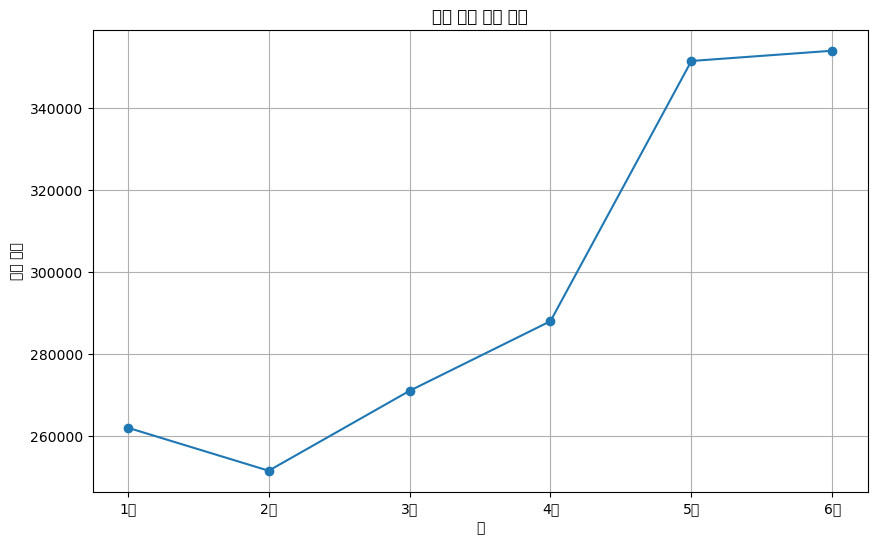

In [5]:
plt.figure()
plt.plot(monthly_totals.index, monthly_totals.values, marker="o")
plt.title("월별 전체 매출 추이")
plt.xlabel("월")
plt.ylabel("매출 합계")
plt.grid(True)
plt.show()


### 해석
- 1~2월은 비수기 흐름
- 3월부터 행사 효과로 반등
- 5월에 가장 큰 폭의 상승
- 6월에도 높은 매출 유지


## 4. 카테고리별 비중 변화 (1월 vs 6월)

In [6]:
cat_jan = df.groupby("카테고리")["1월"].sum().sort_values(ascending=False)
cat_jun = df.groupby("카테고리")["6월"].sum().sort_values(ascending=False)

cat_share = pd.DataFrame({
    "1월매출": cat_jan,
    "6월매출": cat_jun
}).fillna(0)

cat_share["1월비중(%)"] = cat_share["1월매출"] / cat_share["1월매출"].sum() * 100
cat_share["6월비중(%)"] = cat_share["6월매출"] / cat_share["6월매출"].sum() * 100

cat_share.round(2)


,1월매출,6월매출,1월비중(%),6월비중(%)
카테고리,,,,
명품,134000,170000,51.15,48.02
패션,50000,77000,19.08,21.75
식품,43000,48000,16.41,13.56
스포츠,20000,42000,7.63,11.86
리빙,9000,10000,3.44,2.82
키즈,6000,7000,2.29,1.98


c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw

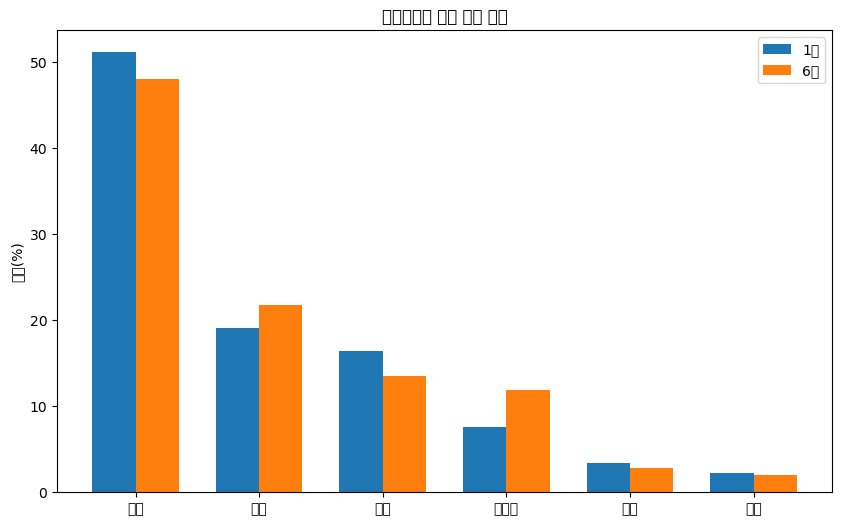

In [7]:
x = np.arange(len(cat_share.index))
width = 0.35

plt.figure()
plt.bar(x - width/2, cat_share["1월비중(%)"], width=width, label="1월")
plt.bar(x + width/2, cat_share["6월비중(%)"], width=width, label="6월")
plt.xticks(x, cat_share.index)
plt.ylabel("비중(%)")
plt.title("카테고리별 매출 비중 변화")
plt.legend()
plt.show()


### 해석
- 명품은 절대 매출은 증가했지만 비중은 소폭 감소
- 패션과 스포츠는 비중이 확대됨
- 스포츠는 리뉴얼 효과가 반영된 것으로 해석 가능


## 5. 브랜드별 목표 달성률

In [8]:
achievement = df[["브랜드", "카테고리", "6개월평균", "목표(월평균)", "목표달성률(%)"]].sort_values(
    by="목표달성률(%)", ascending=False
)

achievement.round(2)


,브랜드,카테고리,6개월평균,목표(월평균),목표달성률(%)
6,브랜드G,스포츠,18500.00,16000,115.62
7,브랜드H,스포츠,12500.00,11000,113.64
3,브랜드D,패션,24666.67,22000,112.12
2,브랜드C,패션,40166.67,38000,105.70
0,브랜드A,명품,92333.33,90000,102.59
5,브랜드F,식품,15333.33,15000,102.22
4,브랜드E,식품,28500.00,28000,101.79
9,브랜드J,키즈,7083.33,7000,101.19
8,브랜드I,리빙,10083.33,10000,100.83
1,브랜드B,명품,47166.67,48000,98.26


c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45804 (\N{HANGUL SYLLABLE DAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io

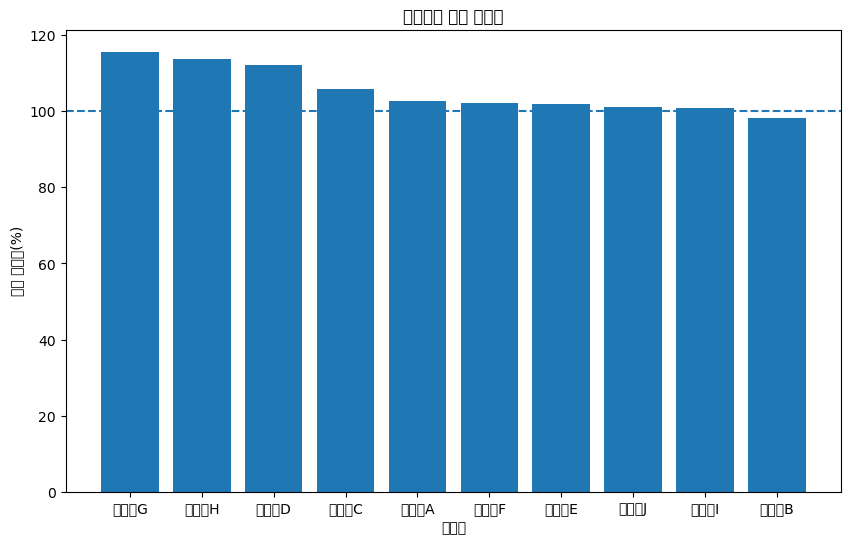

In [9]:
plt.figure()
plt.bar(achievement["브랜드"], achievement["목표달성률(%)"])
plt.axhline(100, linestyle="--")
plt.title("브랜드별 목표 달성률")
plt.xlabel("브랜드")
plt.ylabel("목표 달성률(%)")
plt.show()


### 해석
- 목표 달성률 기준 상위권은 스포츠(G, H)와 패션(D)
- 브랜드B는 유일하게 목표 미달


## 6. 성과 우수 / 부진 브랜드 진단
기준은 목표 달성률과 성장률을 함께 고려합니다.


In [10]:
score_df = df[["브랜드", "카테고리", "목표달성률(%)", "성장률_1월대비6월(%)"]].copy()

# 단순 종합 점수: 목표달성률 + 성장률 가중 합 예시
score_df["종합점수"] = score_df["목표달성률(%)"] * 0.6 + score_df["성장률_1월대비6월(%)"] * 0.4

top3 = score_df.sort_values("종합점수", ascending=False).head(3)
bottom3 = score_df.sort_values("종합점수", ascending=True).head(3)

top3.round(2), bottom3.round(2)


(    브랜드 카테고리  목표달성률(%)  성장률_1월대비6월(%)    종합점수
 7  브랜드H  스포츠    113.64         112.50  113.18
 6  브랜드G  스포츠    115.62         108.33  112.71
 3  브랜드D   패션    112.12          66.67   93.94,
     브랜드 카테고리  목표달성률(%)  성장률_1월대비6월(%)   종합점수
 8  브랜드I   리빙    100.83          11.11  64.94
 4  브랜드E   식품    101.79          10.71  65.36
 5  브랜드F   식품    102.22          13.33  66.67)

c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45804 (\N{HANGUL SYLLABLE DAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io

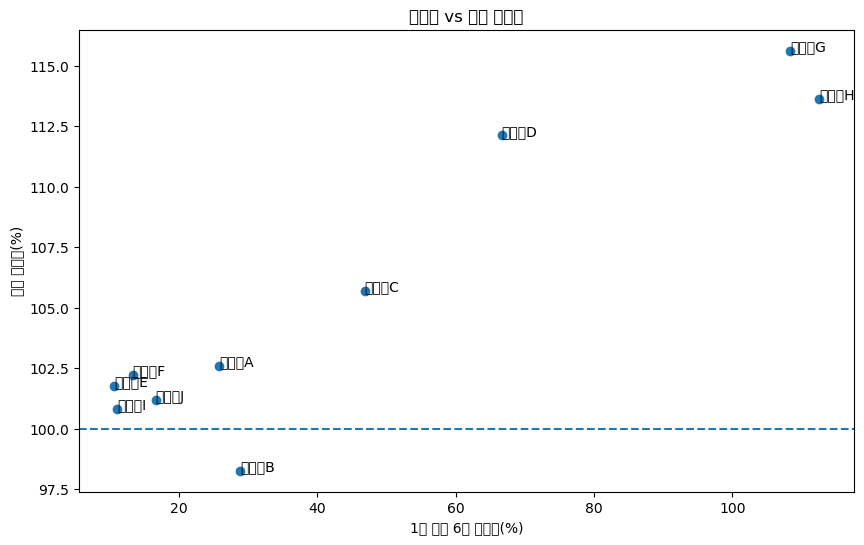

In [11]:
plt.figure()
plt.scatter(df["성장률_1월대비6월(%)"], df["목표달성률(%)"])

for _, row in df.iterrows():
    plt.text(row["성장률_1월대비6월(%)"], row["목표달성률(%)"], row["브랜드"])

plt.axhline(100, linestyle="--")
plt.title("성장률 vs 목표 달성률")
plt.xlabel("1월 대비 6월 성장률(%)")
plt.ylabel("목표 달성률(%)")
plt.show()


### 해석
- 우상단에 위치한 브랜드일수록 성장성과 목표 달성 측면에서 우수
- 스포츠 브랜드는 우상단에 집중
- 브랜드B, I는 상대적으로 낮은 평가 구간에 위치


## 7. 가장 놀라운 변화를 보인 브랜드 찾기

In [12]:
most_surprising = df.loc[df["성장률_1월대비6월(%)"].abs().idxmax(), 
                         ["브랜드", "카테고리", "1월", "6월", "성장률_1월대비6월(%)"]]

most_surprising


브랜드               브랜드H
카테고리               스포츠
1월                8000
6월               17000
성장률_1월대비6월(%)    112.5
Name: 7, dtype: object

### 해석
- 성장률 절대값 기준으로 가장 큰 변화 브랜드를 식별
- 이 데이터에서는 스포츠 리뉴얼 영향이 반영된 브랜드가 유력


## 8. 공간 효율성 분석
매장면적당 매출을 계산해 공간 활용 효율을 비교합니다.


In [13]:
space_eff = df[["브랜드", "카테고리", "매장면적(㎡)", "6개월평균", "면적당매출"]].sort_values(
    by="면적당매출", ascending=False
)

space_eff.round(2)


,브랜드,카테고리,매장면적(㎡),6개월평균,면적당매출
0,브랜드A,명품,250,92333.33,369.33
2,브랜드C,패션,120,40166.67,334.72
3,브랜드D,패션,90,24666.67,274.07
1,브랜드B,명품,180,47166.67,262.04
6,브랜드G,스포츠,100,18500.00,185.00
7,브랜드H,스포츠,80,12500.00,156.25
4,브랜드E,식품,200,28500.00,142.50
5,브랜드F,식품,150,15333.33,102.22
9,브랜드J,키즈,70,7083.33,101.19
8,브랜드I,리빙,110,10083.33,91.67


c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

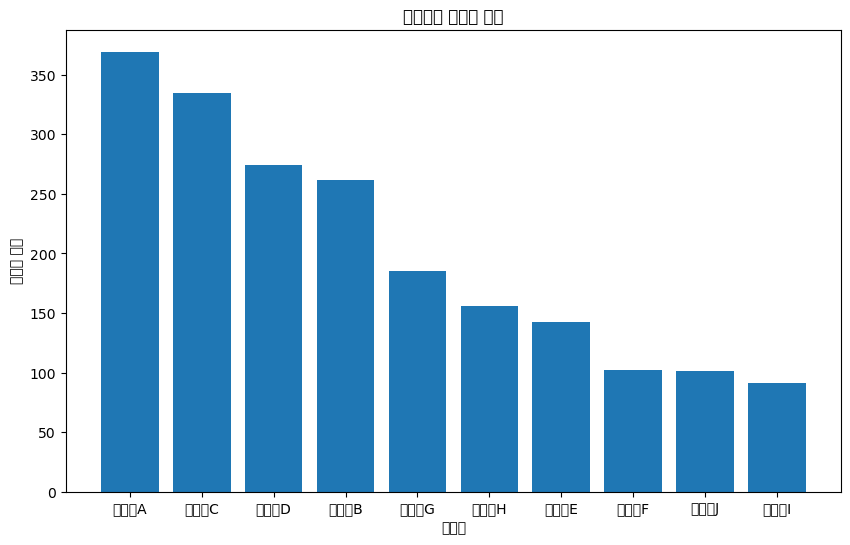

In [14]:
plt.figure()
plt.bar(space_eff["브랜드"], space_eff["면적당매출"])
plt.title("브랜드별 면적당 매출")
plt.xlabel("브랜드")
plt.ylabel("면적당 매출")
plt.show()


In [15]:
highest_eff = space_eff.iloc[0]
lowest_eff = space_eff.iloc[-1]

highest_eff, lowest_eff


(브랜드                브랜드A
 카테고리                 명품
 매장면적(㎡)             250
 6개월평균      92333.333333
 면적당매출        369.333333
 Name: 0, dtype: object,
 브랜드                브랜드I
 카테고리                 리빙
 매장면적(㎡)             110
 6개월평균      10083.333333
 면적당매출         91.666667
 Name: 8, dtype: object)

### 해석
- 브랜드A는 절대 매출과 공간 효율을 동시에 확보
- 브랜드I는 공간 효율이 가장 낮아 면적 재배치 검토가 필요


## 9. 추가 EDA 아이디어
발표 자료나 보고서 확장을 위해 아래 분석도 고려할 수 있습니다.

- 월 x 브랜드 heatmap
- 카테고리별 성장률 비교
- 절대 매출과 효율성의 관계 산점도
- 행사 시점 더미 변수 기반 간단 회귀 분석


In [16]:
# 참고용: 월 x 브랜드 heatmap용 피벗 테이블
pivot_df = df.set_index("브랜드")[month_cols]
pivot_df


,1월,2월,3월,4월,5월,6월
브랜드,,,,,,
브랜드A,89000,95000,78000,82000,98000,112000
브랜드B,45000,48000,39000,41000,52000,58000
브랜드C,32000,28000,41000,38000,55000,47000
브랜드D,18000,15000,22000,28000,35000,30000
브랜드E,28000,24000,32000,27000,29000,31000
브랜드F,15000,12000,18000,14000,16000,17000
브랜드G,12000,10000,14000,22000,28000,25000
브랜드H,8000,7000,9000,15000,19000,17000
브랜드I,9000,7500,11000,12000,11000,10000
